In [2]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from numba import njit

# Assignment 2: Sniping Schrödinger

Daniel Sun

23 January 2026

## 1 Quantum Mechanics on the Computer

The 1D time-independent Schrödinger equation (TISE) can be easily recast into first-order form,
$$\frac{\mathrm{d}}{\mathrm{d}x}\begin{pmatrix}\psi(x)\\\psi'(x)\end{pmatrix}=\begin{pmatrix}\psi'(x)\\-2m(E-V(x))\psi(x)\end{pmatrix}.$$
Note that we can take $\psi$ to be real-valued and unnormalized. To see this, note that if a complex-valued wavefunction $\psi$ satisfies the TISE, then so does its conjugate, $\psi^*$. Since the TISE is linear, this means that $\Re(\psi)=\frac{\psi+\psi^*}{2}$ and $\Im(\psi)=\frac{\psi-\psi^*}{2i}$, which are both real-valued, are also solutions to the TISE. In particular, $\psi=\Re(\psi)+i\Im(\psi)$, so any general solution $\psi$ to the TISE can be written as a $\mathbb C$-linear combination of real-valued solutions to the TISE. Therefore, it suffices to study real-valued solutions to the TISE for our numerics.

In [3]:
@njit
def RK4(f, y0, x0, xf, N):
    """
    RK4 method.
    
    Parameters:
    * f: Derivative function, with call signature f(x, y). Must be Numba-compatible.
    * y0: Initial value (np.ndarray)
    * x0: Initial position (float)
    * xf: Final position (float)
    * N: Number of steps (int)

    Returns:
    * y: Function values (np.ndarray of shape (N + 1, y0.shape[0]))
    """
    x = np.linspace(x0, xf, N + 1)
    y = np.empty((N + 1, y0.shape[0]))
    h = (xf - x0) / N
    y[0] = y0
    for i in range(N):
        k1 = f(x[i], y[i])
        k2 = f(x[i] + h / 2, y[i] + h * k1 / 2)
        k3 = f(x[i] + h / 2, y[i] + h * k2 / 2)
        k4 = f(x[i] + h, y[i] + h * k3)
        y[i + 1] = y[i] + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    return y

In [4]:
def solve_TISE(V, m, E, a, b, psi_a, psi_prime_a, N = 1000):
    """
    RK4 wrapper for solving TISE.

    Parameters:
    * V: Potential function. Must be Numba-compatible.
    * m: Mass (float)
    * E: Energy (float)
    * a: Left boundary (float)
    * b: Right boundary (float)
    * psi_a: Wavefunction at a (float)
    * psi_prime_a: Wavefunction derivative at a (float)
    * N: Number of steps (int, default 1000)

    Returns:
    * psi, psi': Wavefunction and derivative along lattice (np.ndarray of shape (N + 1, 2))
    """
    @njit
    def f(x, y):
        return np.array([y[1], -2 * m * (E - V(x)) * y[0]])
    return RK4(f, np.array([psi_a, psi_prime_a]), a, b, N)

### Free Particle

The normalization for our initial conditions is
$$\psi(x)=\frac1{\sqrt{2mE}}\sin(\sqrt{2mE}x).$$

In [5]:
@njit
def V_free(x):
    return 0.

In [6]:
N = 10000
m = 1
E = 2 * np.pi**2 # Period 1
a = 0
b = 10
psi = solve_TISE(V_free, m, E, a, b, 0, 1, N)[:, 0]
x = np.linspace(a, b, N + 1)

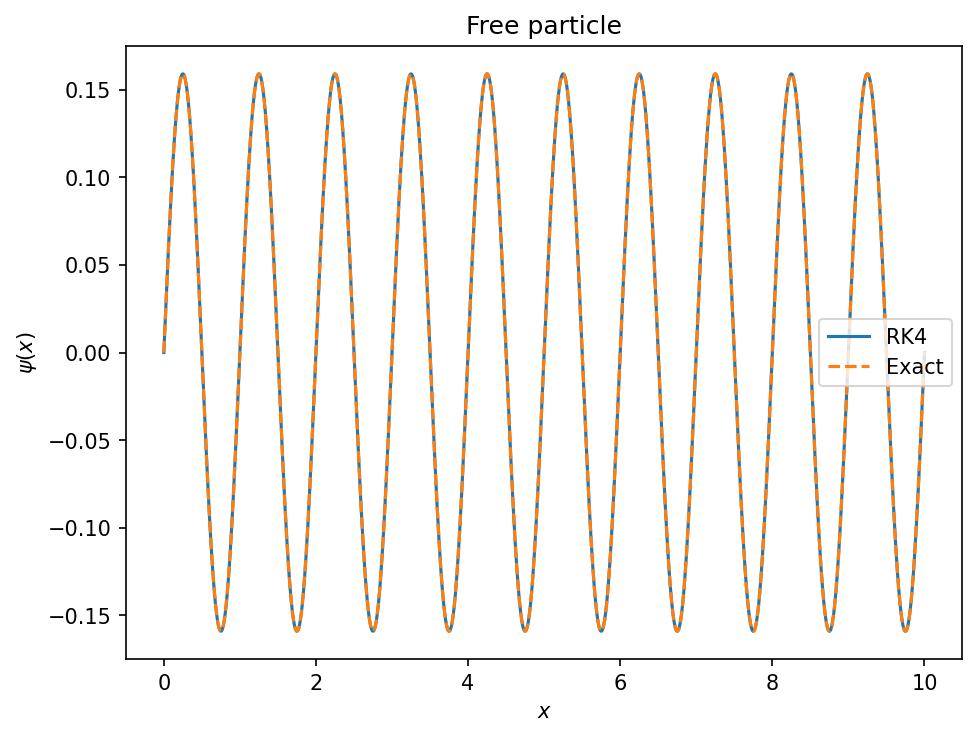

In [7]:
plt.subplots(dpi = 150, layout = "constrained")
plt.plot(x, psi, label = "RK4")
plt.plot(x, np.sin(2 * np.pi * x) / (2 * np.pi), linestyle = "dashed", label = "Exact")
plt.title("Free particle")
plt.xlabel("$x$")
plt.ylabel(r"$\psi(x)$")
plt.legend()

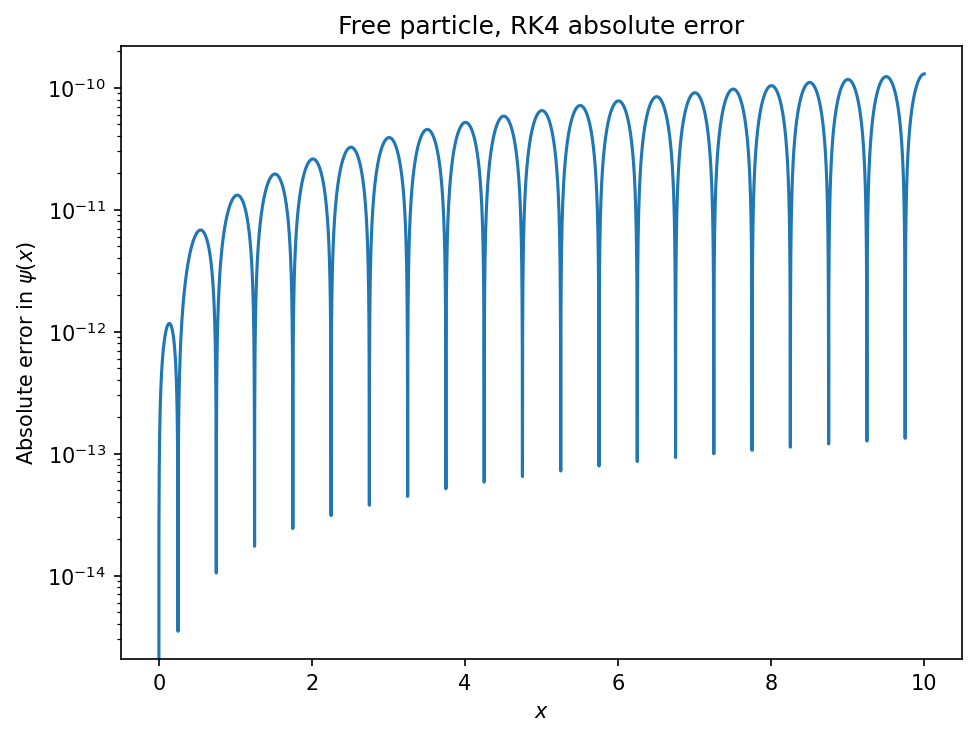

In [8]:
plt.subplots(dpi = 150, layout = "constrained")
plt.plot(x, np.abs(psi - np.sin(2 * np.pi * x) / (2 * np.pi)))
plt.title("Free particle, RK4 absolute error")
plt.xlabel("$x$")
plt.ylabel("Absolute error in $\\psi(x)$")
plt.yscale("log")

### Harmonic Oscillator

The ground state wavefunction is a Gaussian with standard deviation $\sigma_0=\frac1{\sqrt{m\omega}}$. Then, for $a\gg\sigma_0$, the amplitude is exponentially suppressed at the endpoints, so we can fairly assume $\psi_0(-a)\approx0$. In comparison, the derivative of $\psi_0$ is
$$\psi_0'(x)\propto-\frac{x}{\sigma_0^2}e^{-x^2/2\sigma_0^2}.$$
For this to be appreciably larger (numerically) than $\psi_0$ itself at $-a$, we must choose parameters such that $\left|\frac{\psi'(-a)}{\psi(-a)}\right|=\frac{a}{\sigma_0^2}\gg1$, or
$$m\omega\gg\frac1a.$$
However, this must be balanced with the constraint that $e^{-a^2/2\sigma_0^2}$ is not too small. A suitable choice for the exponential term could be about $2^{-40}$, in which case we must choose
$$m\omega=\frac{80\ln2}{a^2}.$$
Note that, for $a=10$, this means that
$$m\omega\approx\frac{5.545}{a}.$$
This isn't great, but the logarithmic dependence of $\left|\frac{\psi'(-a)}{\psi(-a)}\right|$ on the minimum allowed value of $\psi(-a)$ means that there will be quickly diminishing returns. We will choose $m=\frac45\ln2$ and $\omega=1$.

Let's estimate the error in the initial condition, for the ground-state wavefunction. For a Gaussian with amplitude $A_0$, the error of the wavefunction itself is $\left|\psi(-a)\right|=A_02^{-40}$. The error of the derivative is $\left|\psi'(-a)-1\right|=\left|8\ln(2)A_02^{-40}-1\right|$. A good pick for $A_0$ could be one which minimizes the mean-squared error in the wavefunction and its derivative, which it's not hard to show would be at
$$A_0=\frac{2^{43}\ln(2)}{1+64\ln^2(2)}.$$
Then, the root-mean-squared (absolute) error in the initial conditions is
$$\frac1{\sqrt{2+128\ln^2(2)}}\approx0.125.$$
It turns out that this estimate is actually wrong for our numerics; the resulting amplitude of the Gaussian is much lower than our predicted value of $A_0$.

In any case, a good heuristic for us to use to evaluate the quality of our solution is to leverage symmetry. In particular, the parity of the wavefunction should be the same as the parity of the occupation number $n$. Our strategy could then be to choose a starting point $a$ to minimize the mean-squared "oddness" (resp. "evenness"), which we'll define as
$$\varepsilon(a)\equiv\frac1{2a}\int_{-a}^a\mathrm{d}x\left|\psi(x)\mp\psi(-x)\right|^2.$$
It's fine to just evaluate this metric via a Riemann sum.

In [9]:
def V_harm(m, omega):
    @njit
    def V(x):
        return 0.5 * m * omega**2 * x**2
    return V

In [10]:
N = 10000
m = 0.8 * np.log(2)
omega = 1

def epsilon(a, n):
    E = omega * (0.5 + n)
    psi = solve_TISE(V_harm(m, omega), m, E, -a, a, 0, 1, N)[:, 0]
    x = np.linspace(-a, a, N + 1)
    err = (psi - (-1)**(n % 2) * psi[::-1])**2
    return np.trapezoid(err, x) / (2 * a)

In [11]:
a_range = np.logspace(0, 1, 100)
eps = np.zeros_like(a_range)
for i in tqdm(range(a_range.shape[0])):
    eps[i] = epsilon(a_range[i], 0) # Ground state

  0%|          | 0/100 [00:00<?, ?it/s]

Text(0, 0.5, 'Mean-squared parity error')

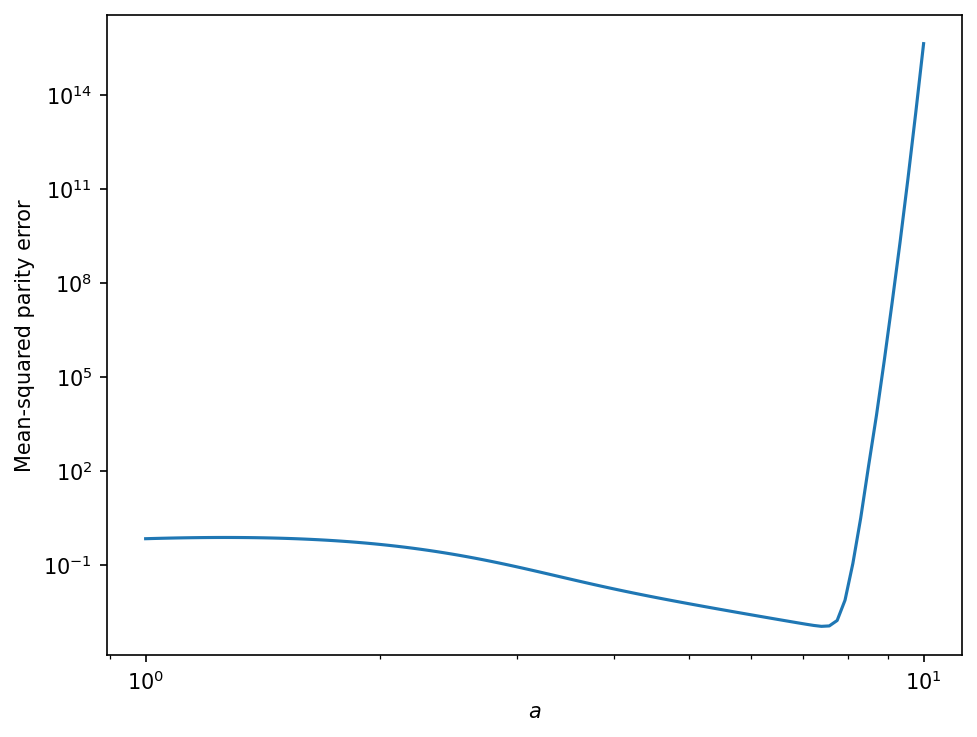

In [12]:
plt.subplots(dpi = 150, layout = "constrained")
plt.plot(a_range, eps)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("$a$")
plt.ylabel("Mean-squared parity error")

In [13]:
print(f"Minimum mean-squared parity error {np.min(eps)} at a = {a_range[np.argmin(eps)]}")

Minimum mean-squared parity error 0.0011150661826254417 at a = 7.390722033525779


In [14]:
a = a_range[np.argmin(eps)]
n = 0 # Ground state
E = omega * (0.5 + n)
psi = solve_TISE(V_harm(m, omega), m, E, -a, a, 0, 1, N)[:, 0]
x = np.linspace(-a, a, N + 1)

Text(0, 0.5, '$\\psi_0(x)$')

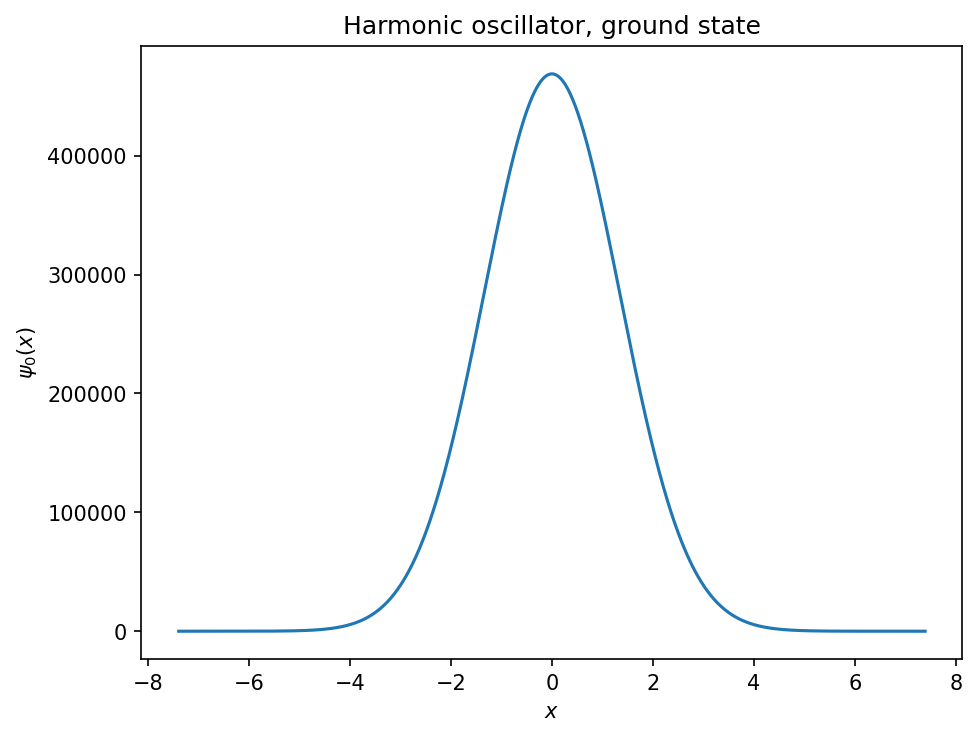

In [15]:
plt.subplots(dpi = 150, layout = "constrained")
plt.plot(x, psi, label = "RK4")
# plt.plot(x, 2**43 * np.log(2) / (1 + 64 * np.log(2)**2) * np.exp(-40 * np.log(2) / a**2 * x**2), linestyle = "dashed", label = "Exact?")
plt.title("Harmonic oscillator, ground state")
plt.xlabel("$x$")
plt.ylabel(r"$\psi_0(x)$")
# plt.legend()

In [16]:
a = a_range[np.argmin(eps)]
n_range = np.linspace(0, 2, 21)
E_range = omega * (0.5 + n_range)
psi_range = np.empty((n_range.shape[0], N + 1))
for i in tqdm(range(n_range.shape[0])):
    psi_range[i] = solve_TISE(V_harm(m, omega), m, E_range[i], -a, a, 0, 1, N)[:, 0]
x = np.linspace(-a, a, N + 1)

  0%|          | 0/21 [00:00<?, ?it/s]

In [17]:
# TODO make slider

(-500000.0, 500000.0)

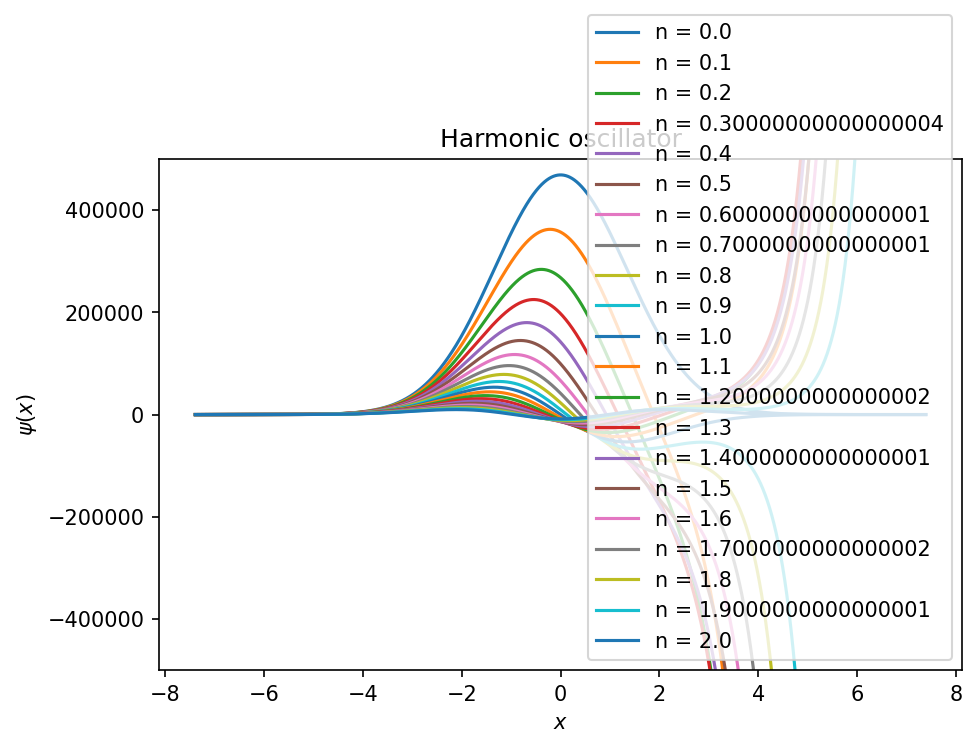

In [18]:
plt.subplots(dpi = 150, layout = "constrained")
for i in range(n_range.shape[0]):
    plt.plot(x, psi_range[i], label = f"n = {n_range[i]}")
plt.title("Harmonic oscillator")
plt.xlabel("$x$")
plt.ylabel(r"$\psi(x)$")
plt.legend()
plt.ylim(-500000, 500000)